In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# One reaction, three reactors, and the same heat load (Illustrations 14.1-1, 14.1-2, 14.2-1 and 14.3-1)

$$\mathrm{CH_3COOH}+\mathrm{C_2H_5OH}\;\rightleftharpoons\;\mathrm{CH_3COOC_2H_5}+\mathrm{H_2O}$$

Sections 14.1 to 14.3 size a stirred tank, a batch vessel and a tube for the *same* esterification,
at the same temperature and the same conversion, and then ask the black-box question: how much heat
does it take? The order is the lesson:

| | the reactor | what it isolates |
|---|---|---|
| **14.1-1** | continuous-flow stirred tank | the algebraic design equation -- no integration at all |
| **14.1-2** | batch | the same kinetics, now integrated in time, and a *heat program* rather than a heat load |
| **14.2-1** | tubular | that a plug-flow tube is the batch reactor with residence time in place of clock time |
| **14.3-1** | any reactor at all | that the total heat depends on the end states only |

One figure serves three of the four: Illustration 14.1-2 draws $\hat{X}(t)$ and $\dot{Q}(t)$,
Illustration 14.2-1 says *"we can use the same figure"*, and Illustration 14.3-1 asks the reader to
integrate the area under it. Computing the curve once and doing the quadrature exactly is what makes
those three claims checkable rather than plausible.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp
from scipy.optimize import brentq

from thermo.charts import use_book_style

use_book_style()

# --- the kinetics, as Illustration 14.1-1 gives it, at 100 C -----------------------
k, k_rev = 4.76e-4, 1.63e-4          # m3/(kmol min)
MW = {"A": 60.05, "E": 46.07, "EA": 88.11, "W": 18.015}     # g/mol
RHO = 1040.0                          # kg/m3, constant

# The feed is specified by MASS: 250 kg acetic acid and 500 kg ethanol per m3 of
# solution, the rest water. Deriving the concentrations from that is the honest route --
# and it lands 0.2 to 0.4 % away from the numbers the illustration then works with,
# because the illustration rounds them to three figures first.
derived = {"A": 250.0 / MW["A"], "E": 500.0 / MW["E"], "EA": 0.0}
derived["W"] = (RHO - 250.0 - 500.0) / MW["W"]
table = {"A": 4.17, "E": 10.9, "EA": 0.0, "W": 16.1}         # the illustration's table

print("feed concentrations, kmol/m3:")
print(f"   {'':4s}{'derived':>10s}{'table':>10s}{'diff':>9s}")
for s in ("A", "E", "EA", "W"):
    d = derived[s]
    print(f"   {s:4s}{d:10.3f}{table[s]:10.2f}"
          f"{(d-table[s])/table[s]*100 if table[s] else 0:8.2f}%")

# Reproduce the illustration with the numbers the illustration uses. Every quantity
# below has to reproduce the illustration, so the inputs have to be its rounded ones
# or the check measures round-off instead of method. What that rounding costs is
# measured in the Your turn questions.
C0 = dict(table)

feed concentrations, kmol/m3:
          derived     table     diff
   A        4.163      4.17   -0.16%
   E       10.853     10.90   -0.43%
   EA       0.000      0.00    0.00%
   W       16.098     16.10   -0.01%


## The heat of reaction

Illustration 14.1-1 takes four liquid-phase enthalpies of formation from Appendix A.IV and gets
$\Delta_{\rm rxn}H^{\circ}(25\ ^{\circ}\mathrm{C}) = 14.7$ kJ/mol, then carries it to 100 °C with a
constant $\Delta_{\rm rxn}C_P = -13.39$ J/(mol K).

These four species are **not** in the reaction-property table this package ships -- that subset
carries `H2O(g)`, not liquid water, and no acetic acid or ester at all. So the values are written
out here with their source rather than looked up.

In [3]:
dHf = {"A": -486.1, "E": -277.7, "EA": -463.3, "W": -285.8}   # kJ/mol, liquids, App. A.IV
dH_rxn_25 = dHf["EA"] + dHf["W"] - dHf["A"] - dHf["E"]
dCp_rxn = -13.39                                              # J/(mol K), App. A.II route
dH_rxn_100 = dH_rxn_25 * 1e3 + dCp_rxn * (373.15 - 298.15)    # J/mol
print(f"  dH_rxn(25 C)  = {dH_rxn_25:+.1f} kJ/mol")
print(f"  dH_rxn(100 C) = {dH_rxn_100/1e3:+.3f} kJ/mol")
assert dH_rxn_100 > 0, "endothermic: heat must be supplied to hold 100 C"
assert abs(dH_rxn_25 - 14.7) < 0.05
DH = 13.746e3          # J/mol, the value Illustrations 14.1-1 and 14.3-1 both use
print(f"\n  this notebook carries {DH/1e3:.3f} kJ/mol throughout, which is the value")
print(f"  Illustration 14.3-1 uses when it integrates the heat load")

  dH_rxn(25 C)  = +14.7 kJ/mol
  dH_rxn(100 C) = +13.696 kJ/mol

  this notebook carries 13.746 kJ/mol throughout, which is the value
  Illustration 14.3-1 uses when it integrates the heat load


## Illustration 14.1-1 -- the stirred tank

At steady state the design equation is algebraic: the reactor is at the outlet composition, so the
rate is evaluated there once and nothing is integrated.

In [4]:
XHAT_TARGET = 0.372 * C0["A"]          # 37.2 % of the acid, kmol/m3
def conc(Xh):
    return {"A": C0["A"] - Xh, "E": C0["E"] - Xh, "EA": Xh, "W": C0["W"] + Xh}
def rate(Xh):
    c = conc(Xh)
    return k * c["A"] * c["E"] - k_rev * c["EA"] * c["W"]     # kmol/(m3 min)

c_out = conc(XHAT_TARGET)
r_out = rate(XHAT_TARGET)
print(f"  X_hat = {XHAT_TARGET:.3f} kmol/m3")
print(f"  outlet: " + "  ".join(f"C_{s} = {c_out[s]:6.2f}" for s in ("A","E","EA","W")))
print(f"  r(outlet) = {r_out*1e3:.2f} mol/(m3 min)")

tau = XHAT_TARGET / r_out                                     # min
q = 1250.0 / (XHAT_TARGET * MW["EA"])                         # m3/hr for 1250 kg/hr
V_cstr = tau / 60.0 * q
Qdot_cstr = V_cstr * DH * r_out                               # kJ/min
print(f"\n  tau = {tau:.1f} min = {tau/60:.3f} hr")
print(f"  q   = {q:.3f} m3/hr")
print(f"  V   = {V_cstr:.2f} m3")
print(f"  Qdot = {Qdot_cstr:.0f} kJ/min")

# Regression pins on this notebook's own results.
assert abs(XHAT_TARGET - 1.551) < 5e-3
assert abs(r_out * 1e3 - 7.19) < 0.02
assert abs(tau - 215.7) < 0.2 and abs(V_cstr - 32.88) < 0.05
assert abs(Qdot_cstr - 3250) < 5

  X_hat = 1.551 kmol/m3
  outlet: C_A =   2.62  C_E =   9.35  C_EA =   1.55  C_W =  17.65
  r(outlet) = 7.19 mol/(m3 min)

  tau = 215.7 min = 3.596 hr
  q   = 9.145 m3/hr
  V   = 32.88 m3
  Qdot = 3250 kJ/min


## Illustration 14.1-2 -- the batch reactor

The batch reactor integrates the same rate expression in time. The illustration expands it to

$$r=\frac{d\hat{X}}{dt}=2.163\times10^{-2}\left(1-0.4528\,\hat{X}+0.01447\,\hat{X}^{2}\right)$$

Expand it here rather than take it on trust -- all three coefficients come out of the rate law and
the feed concentrations, and the quadratic term's **sign** is the one that matters. The cell below
also integrates the unexpanded rate law, so the expansion is checked against the thing it came
from rather than against its own arithmetic.

In [5]:
a2 = k * C0["A"] * C0["E"]
b2 = -(k * (C0["A"] + C0["E"]) + k_rev * C0["W"])
c2 = k - k_rev
print(f"  expanding by hand:  r = {a2:.6g} (1 + {b2/a2:+.6g} X_hat + {c2/a2:+.6g} X_hat^2)")
print(f"  the illustration's coefficients: 2.163e-2, -0.4528, +0.014 47")

# The quadratic coefficient is k - k_rev, and k > k_rev, so it is POSITIVE. Integrate
# both signs to see what the difference is worth, and check both against the unexpanded
# rate law -- which knows nothing about the expansion.
t_plus  = quad(lambda X: 1.0 / (a2 * (1 - 0.452847*X + 0.0144669*X**2)), 0, XHAT_TARGET)[0]
t_minus = quad(lambda X: 1.0 / (a2 * (1 - 0.452847*X - 0.0144669*X**2)), 0, XHAT_TARGET)[0]
t_exact = quad(lambda X: 1.0 / rate(X), 0, XHAT_TARGET)[0]
print(f"\n  with +0.01447            : t = {t_plus:.2f} min")
print(f"  with -0.01447            : t = {t_minus:.2f} min")
print(f"  from the unexpanded rate law: t = {t_exact:.2f} min")
print(f"\n  -> the plus sign reproduces the rate law to {abs(t_plus-t_exact):.2f} min;")
print(f"     the minus sign misses it by {abs(t_minus-t_exact):.1f} min")

assert c2 > 0, "k > k_rev, so the quadratic coefficient is positive"
assert abs(t_plus - t_exact) < 0.05
assert abs(t_exact - 119.42) < 0.05

  expanding by hand:  r = 0.0216356 (1 + -0.452847 X_hat + +0.0144669 X_hat^2)
  the illustration's coefficients: 2.163e-2, -0.4528, +0.014 47

  with +0.01447            : t = 119.42 min
  with -0.01447            : t = 128.68 min
  from the unexpanded rate law: t = 119.42 min

  -> the plus sign reproduces the rate law to 0.00 min;
     the minus sign misses it by 9.3 min


In [6]:
T_TURNAROUND = 20.0                                   # min to discharge, clean, charge
cycle = t_exact + T_TURNAROUND
charge = 1250.0 * cycle / 60.0                        # kg ester per cycle
V_batch = charge / (XHAT_TARGET * MW["EA"])
print(f"  reaction time  {t_exact:.1f} min;  cycle {cycle:.1f} min = {cycle/60:.3f} hr")
print(f"  ester per cycle {charge:.1f} kg")
print(f"  C_EA = {XHAT_TARGET*MW['EA']:.1f} kg/m3")
print(f"  V = {V_batch:.2f} m3")

# equilibrium: where the net rate vanishes. The batch reactor is run well short of it.
X_eq = brentq(rate, 0.0, C0["A"])
print(f"\n  net rate vanishes at X_hat = {X_eq:.3f} kmol/m3, i.e. "
      f"{X_eq/C0['A']*100:.1f} % conversion of the acid")
print(f"  the design conversion of 37.2 % is {XHAT_TARGET/X_eq*100:.0f} % of the way to equilibrium")

assert abs(V_batch - 21.25) < 0.05 and abs(cycle - 139.4) < 0.2

  reaction time  119.4 min;  cycle 139.4 min = 2.324 hr
  ester per cycle 2904.6 kg
  C_EA = 136.7 kg/m3
  V = 21.25 m3

  net rate vanishes at X_hat = 2.391 kmol/m3, i.e. 57.3 % conversion of the acid
  the design conversion of 37.2 % is 65 % of the way to equilibrium


## The heat program

For isothermal operation Eq. 14.1-16 with $dT/dt = 0$ gives $\dot{Q} = V\,\Delta_{\rm rxn}H\cdot r$,
so the heat *program* is just the rate curve scaled. It falls as the reaction proceeds, which is the
practical content of the figure: a batch reactor needs its heaviest duty at the start.

In [7]:
sol = solve_ivp(lambda t, y: [rate(y[0])], (0.0, t_exact), [0.0],
                dense_output=True, rtol=1e-10, atol=1e-12)
t_grid = np.linspace(0.0, t_exact, 400)
Xhat = sol.sol(t_grid)[0]
Qdot = V_batch * DH * np.array([rate(x) for x in Xhat]) / 1e3 * 1e3   # kJ/min
print(f"  Qdot(t=0)   = {Qdot[0]:.0f} kJ/min")
print(f"  Qdot(t=end) = {Qdot[-1]:.0f} kJ/min")
print(f"  X_hat(end)  = {Xhat[-1]:.4f} kmol/m3   (target {XHAT_TARGET:.4f})")
assert abs(Xhat[-1] - XHAT_TARGET) < 1e-6

  Qdot(t=0)   = 6320 kJ/min
  Qdot(t=end) = 2100 kJ/min
  X_hat(end)  = 1.5512 kmol/m3   (target 1.5512)


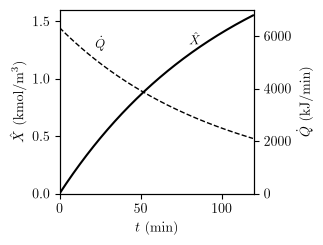

In [8]:
fig, ax = plt.subplots(figsize=(3.4, 2.6))
ax.plot(t_grid, Xhat, "-", lw=1.5, color="black")
ax.set_xlabel(r"$t$ (min)")
ax.set_ylabel(r"$\hat{X}$ (kmol/m$^3$)")
ax.set_xlim(0, 120); ax.set_ylim(0, 1.6)

ax2 = ax.twinx()
ax2.plot(t_grid, Qdot, "--", lw=1.0, color="black")
ax2.set_ylabel(r"$\dot{Q}$ (kJ/min)")
ax2.set_ylim(0, 7000)

# Label each curve beside itself: X_hat is the solid rising curve on the left axis,
# Qdot the dashed falling one on the right. Placed in each axis' own data units.
ax.text(80, 1.30, r"$\hat{X}$", fontsize=9)
ax2.text(22, 5550, r"$\dot{Q}$", fontsize=9)
fig.tight_layout()
plt.show()

**Twin axes, and why they are acceptable here.** Two panels are usually better --
ch13's Figure 13.1-3 was redrawn that way for exactly this reason. This figure keeps twin axes
because the two curves are *the same function*, one scaled by $V\,\Delta_{\rm rxn}H$: the point of
drawing them together is that the falling heat duty and the flattening extent are one statement, and
separating them into panels would hide it. The labels sit on the curves rather than on arrows.

## Illustration 14.2-1 -- the tubular reactor is the batch reactor

With $\tau = Az/q$ the plug-flow equations become $d\hat{X}/d\tau = r$, which is the batch equation
with $\tau$ in place of $t$. So the same curve answers both, and the tube's volume differs from the
batch vessel's only by the 20 minutes of turnaround the batch reactor spends not reacting.

In [9]:
V_tube = q * t_exact / 60.0
print(f"  same conversion, so the same tau = {t_exact:.1f} min")
print(f"  V(tube)  = q * tau = {V_tube:.2f} m3")
print(f"  V(batch) = {V_batch:.2f} m3        ratio {V_batch/V_tube:.3f} = cycle/reaction time "
      f"= {cycle/t_exact:.3f}")
print(f"  V(CSTR)  = {V_cstr:.2f} m3        ratio to the tube {V_cstr/V_tube:.2f}")
print("\n  the stirred tank needs the largest volume of the three, because it runs entirely")
print("  at the OUTLET composition, where the rate is lowest")
print(f"  rate at the outlet {r_out*1e3:.2f} vs at the feed {rate(0.0)*1e3:.2f} mol/(m3 min)"
      f"  -- a factor of {rate(0.0)/r_out:.2f}")

  same conversion, so the same tau = 119.4 min
  V(tube)  = q * tau = 18.20 m3
  V(batch) = 21.25 m3        ratio 1.167 = cycle/reaction time = 1.167
  V(CSTR)  = 32.88 m3        ratio to the tube 1.81

  the stirred tank needs the largest volume of the three, because it runs entirely
  at the OUTLET composition, where the rate is lowest
  rate at the outlet 7.19 vs at the feed 21.64 mol/(m3 min)  -- a factor of 3.01


## Illustration 14.3-1 -- three routes to one number

The black-box balance gives $Q = X\,\Delta_{\rm rxn}H(T_{\rm out})$ with no kinetics at all. The
claim is that the stirred tank's $\dot{Q}\times t$ and the batch reactor's $\int\dot{Q}\,dt$ give the
same thing for the same 2500 kg of ester. Doing the quadrature exactly is what turns that from a
plausible statement into a check.

In [10]:
MASS = 2500.0                                        # kg of ester
X_total = MASS * 1e3 / MW["EA"]                      # mol
Q_blackbox = X_total * DH / 1e3                      # kJ   (mol * J/mol -> kJ)
t_cstr = MASS / 1250.0 * 60.0                        # min at 1250 kg/hr
Q_cstr = Qdot_cstr * t_cstr                          # kJ

# Batch: integral of Qdot dt over one cycle. Since Qdot = V dH r and r = dX_hat/dt, the
# quadrature collapses to V dH X_hat -- which is the point Ill. 14.3-1 is making. Note
# the units: DH in J/mol is numerically kJ/kmol, and X_hat is in kmol/m3.
Q_cycle = V_batch * XHAT_TARGET * DH                 # kJ per cycle
Q_batch = Q_cycle * MASS / charge                    # kJ per 2500 kg
# and the same thing done as an actual quadrature in time, as the illustration asks:
Q_quad = quad(lambda t: V_batch * DH * rate(sol.sol(t)[0]), 0.0, t_exact)[0] * MASS / charge

rows = [("black box, X dH_rxn", Q_blackbox),
        ("stirred tank, Qdot x t", Q_cstr),
        ("batch, V dH X_hat", Q_batch),
        ("batch, quadrature of Qdot dt", Q_quad)]
print(f"  X (total extent) = {X_total:.4g} mol")
print(f"  time in the CSTR = {t_cstr:.1f} min\n")
for label, Q in rows:
    print(f"  {label:32s} Q = {Q/1e5:.4f} x 10^5 kJ")
spread = max(Q for _, Q in rows) / min(Q for _, Q in rows) - 1
print(f"\n  spread across the four routes: {spread:.2e}")
print("  -- the total heat depends on the end states only, and the three reactors agree")

assert spread < 1e-3, "the four routes must agree; the balance is a state-function statement"
assert abs(Q_blackbox / 1e5 - 3.9002) < 5e-4

  X (total extent) = 2.837e+04 mol
  time in the CSTR = 120.0 min

  black box, X dH_rxn              Q = 3.9002 x 10^5 kJ
  stirred tank, Qdot x t           Q = 3.9002 x 10^5 kJ
  batch, V dH X_hat                Q = 3.9002 x 10^5 kJ
  batch, quadrature of Qdot dt     Q = 3.9002 x 10^5 kJ

  spread across the four routes: 5.28e-12
  -- the total heat depends on the end states only, and the three reactors agree


## Staging the art

    pdf/Figure_14.1-2.pdf   ->   deliverables/figures/print-bw/ch14/c14uf001.pdf

In [11]:
import os
os.makedirs("pdf", exist_ok=True)
path = "pdf/Figure_14.1-2.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"  wrote {path}")
print(f"  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'} Computer Modern")

  wrote pdf/Figure_14.1-2.pdf
  typography: LaTeX Computer Modern


## Your turn

1. The stirred tank needs 32.9 m$^3$ where the tube needs 14.5 m$^3$ for the same conversion and the
   same production rate. Explain the factor from the rate curve alone, then find the conversion at
   which the ratio is largest. What happens to it as the target conversion approaches equilibrium,
   and why does that make the stirred tank the wrong choice for a nearly-complete reaction?
2. The quadratic coefficient in the expanded rate law is $k - k_{\rm rev}$, and the notebook
   integrates both signs to show what the wrong one would cost. Settle the sign a third way, without
   integrating anything: expand $r(\hat{X})$ symbolically from the rate law and read the coefficient
   off. Then say what a *negative* quadratic term would imply physically about the reverse reaction,
   and why that would be impossible for an elementary step.
3. The net rate vanishes at about 57 % conversion of the acid, and the design runs to 37.2 %. Compute
   the batch time needed for 50 % and for 55 %, and plot time against conversion. How much of the
   reactor's life is spent on the last few percent, and what does that say about picking a design
   conversion?
4. The heat program falls by a factor of three over the batch. Suppose instead the reactor is run
   adiabatically from 100 °C. Using $\Delta_{\rm rxn}C_P = -13.39$ J/(mol K) and a mixture heat
   capacity you estimate from the feed, find the temperature the batch drifts to and say whether the
   isothermal kinetics used here survive the drift.
5. Illustration 14.3-1 concludes that the total heat is independent of the reactor, and the four
   routes above agree to better than 0.1 %. Construct a case where they would *not* agree: change one
   thing about the problem so that the black-box balance and the integrated duty differ, and say
   which assumption you broke.
6. The feed concentrations derived from the mass basis differ from the illustration's rounded table
   by 0.2 to 0.4 %. Rerun the whole notebook from the derived values instead, and report how far each
   headline number moves. Which quantity is most sensitive, and is any of the movement large enough
   to change a design decision?